# 05. SWE agent: от задачи до проверенного изменения


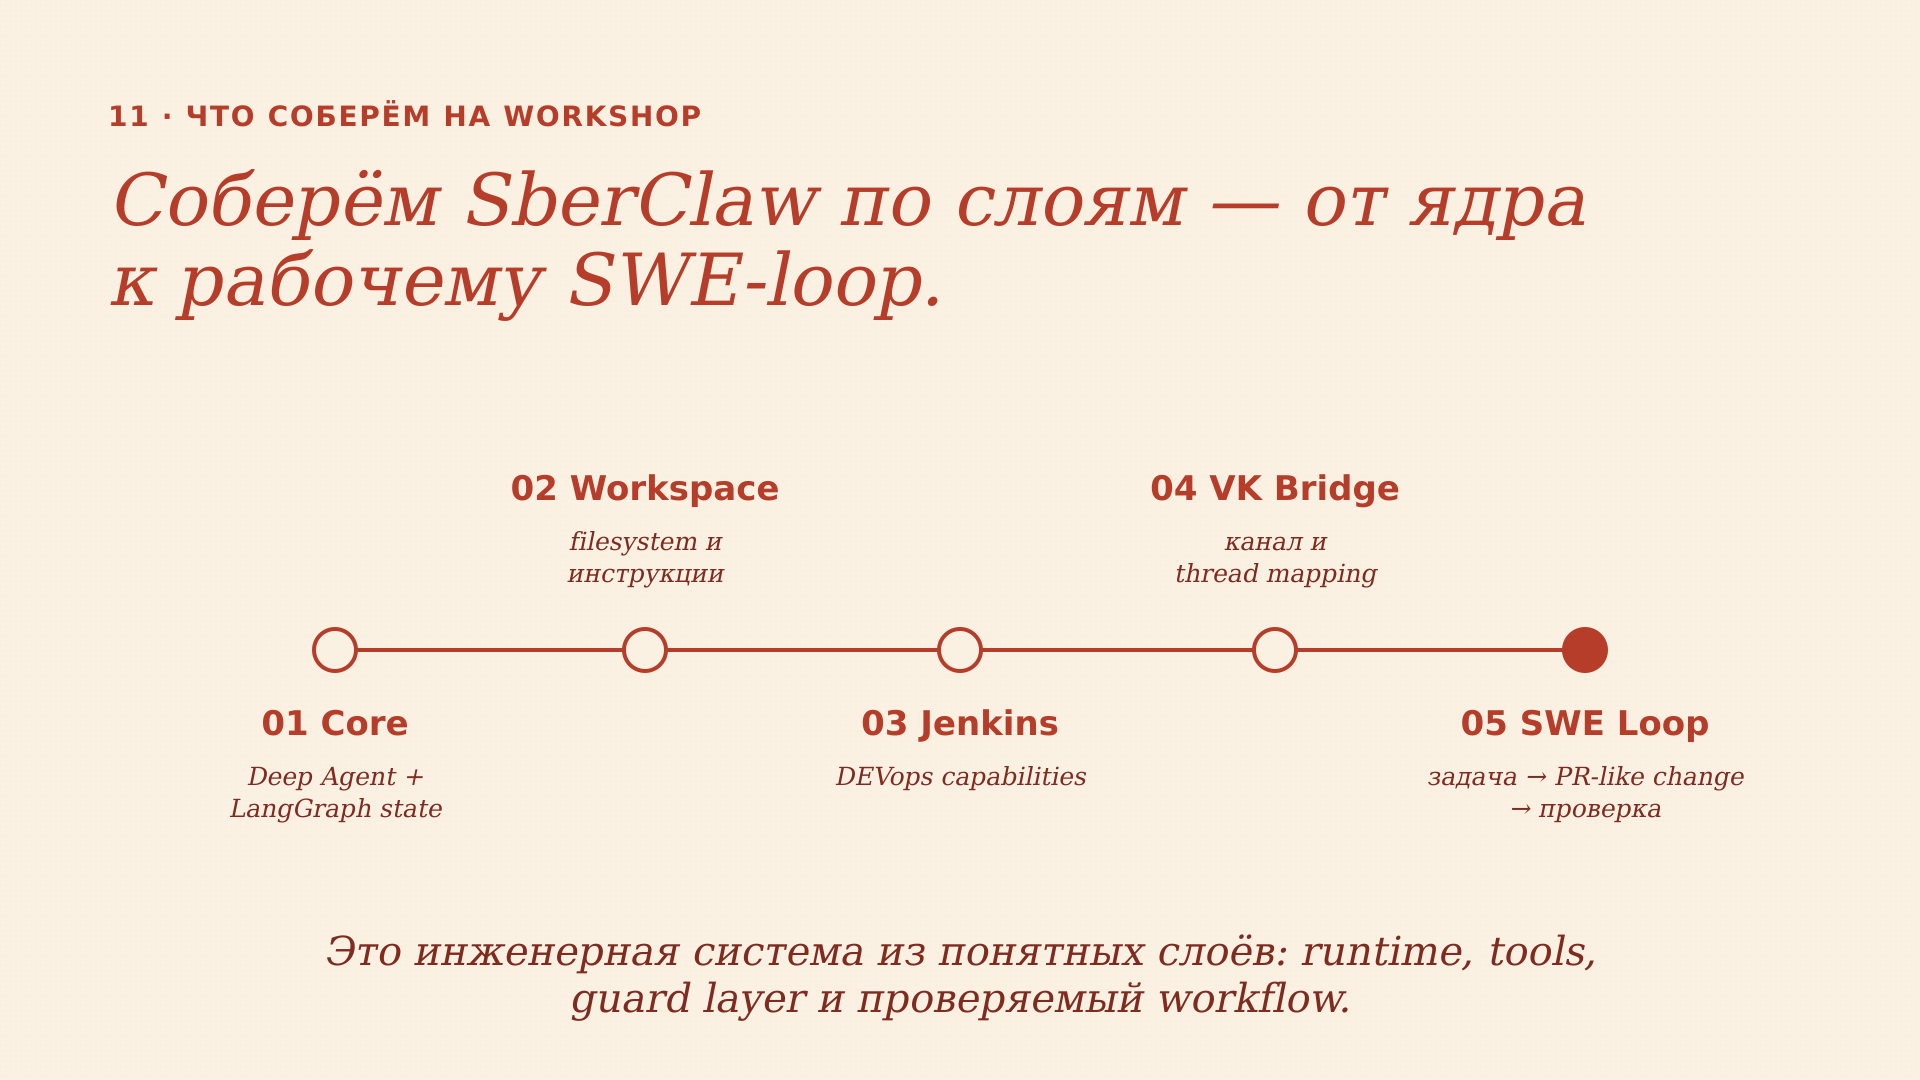

## Acceptance criteria для SWE-задачи

```text
VK connector должен разбивать сообщения длиннее 3500 символов.

1. Каждый chunk не длиннее 3500 символов.
2. Порядок и полный текст сохраняются.
3. Пустые chunks не отправляются.
4. Каждый chunk отправляется отдельным вызовом VK API.
5. Каждый chunk получает отдельный `random_id`.
6. Tool возвращает structured summary или список результатов отправки.
7. Добавить unit tests без реального сетевого запроса.
8. Запустить только релевантные pytest.
9. Перед финальным ответом передать patch-reviewer git diff и результаты тестов.
```

Сейчас дефект воспроизводим: bridge содержит `reply[:3500]`, а connector не имеет chunking helper.


In [ ]:
from pathlib import Path
import sys

for candidate in (Path.cwd(), Path.cwd() / 'workshop_notebooks' / 'openclaw_path'):
    if (candidate / 'workshop_utils.py').exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from workshop_utils import REPO_ROOT, print_stage_context, register_graphs, write_text

print_stage_context(require_shell=True)


In [ ]:
ENTRYPOINT = '''\
from __future__ import annotations

from pathlib import Path
from deepagents import create_deep_agent
from dotenv import load_dotenv
from agents.model_config import workshop_model
from connectors.jenkins import JENKINS_TOOLS
from connectors.vk import VK_TOOLS

REPO_ROOT = Path(__file__).resolve().parents[1]

load_dotenv(REPO_ROOT / ".env")

def _workspace_root() -> Path:
    return REPO_ROOT


def _backend(*, require_shell: bool = False):
    from deepagents.backends import LocalShellBackend

    return LocalShellBackend(
        root_dir=_workspace_root(),
        virtual_mode=True,
        inherit_env=False,
        timeout=120,
        max_output_bytes=80_000,
    )

TOOLS = [*JENKINS_TOOLS, *VK_TOOLS]
SUBAGENTS = [
    {"name": "repo-researcher", "description": "Research repository facts before implementation.", "system_prompt": "Find relevant files, APIs, tests, and risks. Cite paths."},
    {"name": "patch-reviewer", "description": "Review concrete diffs and test coverage.", "system_prompt": "Review correctness, regressions, tests, and security. Expect the main agent to pass git diff and test results."},
]
SWE_PROMPT = """\
You are OpenClaw SWE agent. Respond in the user's language; default to Russian.
Follow this issue-resolution loop:
1. Reproduce or characterize the issue.
2. Localize relevant files and tests.
3. Patch the root cause.
4. Add or update regression coverage.
5. Run narrow tests first, then related checks.
6. Before delegating to patch-reviewer, run git diff for changed files and include the diff and test results in the reviewer task.
"""
swe_agent = create_deep_agent(
    model=workshop_model(),
    tools=TOOLS,
    system_prompt=SWE_PROMPT,
    subagents=SUBAGENTS,
    backend=_backend(require_shell=True),
)
'''

entrypoint = write_text('agents/openclaw_05_swe_agent.py', ENTRYPOINT)
config_path = register_graphs({
    'openclaw_05_swe': './agents/openclaw_05_swe_agent.py:swe_agent'
})

print("Entrypoint:", entrypoint.relative_to(REPO_ROOT))
print("LangGraph config:", config_path.relative_to(REPO_ROOT))


## Проверка в LangGraph Studio

### Запрос

```text
VK connector должен разбивать сообщения длиннее 3500 символов на несколько частей. Реализуй acceptance criteria из notebook и добавь unit tests без реального VK API.
```

### Ожидаемое поведение

1. Агент локализует `connectors/vk.py`, `scripts/vk_langgraph_bridge.py`, tests.
2. Создаёт/обновляет тест на длинное сообщение.
3. Вносит минимальный patch.
4. Запускает narrow pytest.
5. Передаёт `git diff` и test results в `patch-reviewer`.

### Что изменилось относительно предыдущего этапа

Появился полный SWE workflow: issue → research → edit → test → review → summary.

### Текущее ограничение

Это учебный SWE контур. Нет production isolation, scheduler, полноценной memory subsystem и marketplace skills.
